# Flash IDPS - Complete Workflow Guide
## Understanding Provenance-Based Intrusion Detection Systems

This notebook provides a comprehensive explanation of how **Flash IDPS** works - a provenance-based intrusion detection system that identifies cyber attacks by analyzing system audit logs and building provenance graphs.

---

## Table of Contents

1. [What is Flash IDPS?](#what-is-flash-idps)
2. [System Architecture Overview](#system-architecture-overview)
3. [Step-by-Step Pipeline](#step-by-step-pipeline)
4. [Code Examples with Visualizations](#code-examples-with-visualizations)
5. [Running Flash IDPS](#running-flash-idps)
6. [Docker vs Local Setup](#docker-vs-local-setup)

---

## What is Flash IDPS?

**Flash IDPS** is a provenance-based intrusion detection system that:
- **Monitors** system-level events (process execution, file operations, network connections)
- **Learns** normal system behavior patterns through self-supervised learning
- **Detects** advanced persistent threats (APTs) and malware activities
- **Alerts** security analysts when anomalous behavior is identified

### Security Analogy

Think of Flash IDPS as a **Security Operations Center (SOC)** analyst:
- **Normal activity**: Legitimate user processes accessing expected resources
- **Suspicious activity**: A process like `svchost.exe` making unexpected network connections to command-and-control servers

Flash IDPS automates this detection at scale, processing millions of system events per day.

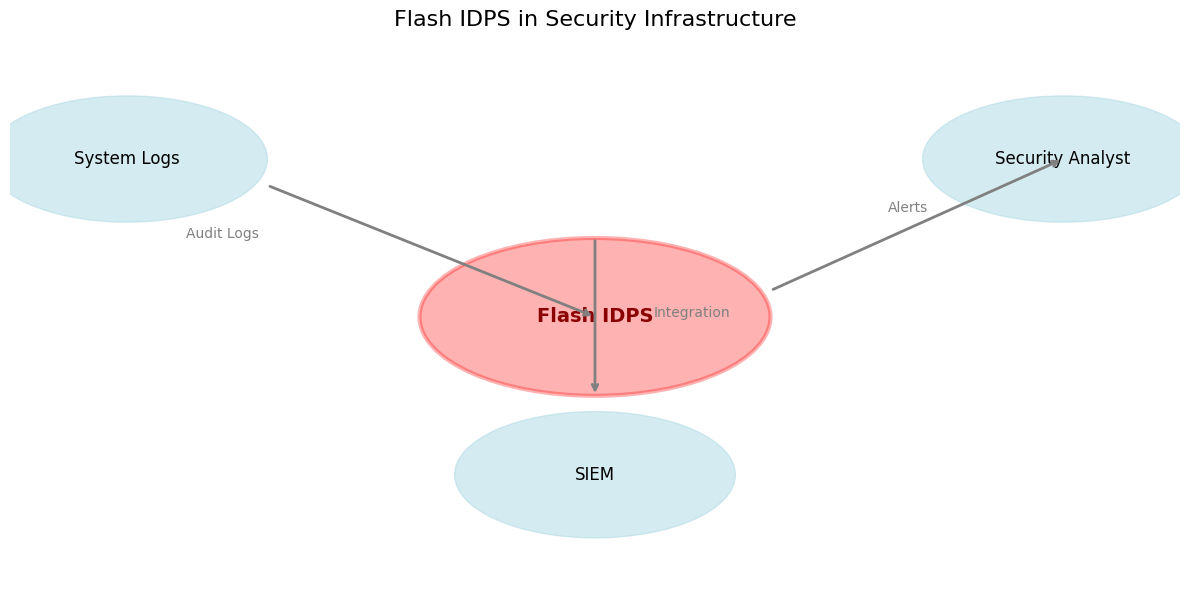

In [1]:
# Visualization: Flash IDPS in a Security Infrastructure
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display, Markdown

# Create a visual representation of where Flash IDPS fits
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

# Security infrastructure diagram
components = {
    'System Logs': (0.1, 0.8),
    'Flash IDPS': (0.5, 0.5),
    'Security Analyst': (0.9, 0.8),
    'SIEM': (0.5, 0.2)
}

for name, (x, y) in components.items():
    if name == 'Flash IDPS':
        circle = plt.Circle((x, y), 0.15, color='red', fill=True, alpha=0.3, linewidth=3)
        ax.add_patch(circle)
        ax.text(x, y, name, ha='center', va='center', fontsize=14, fontweight='bold', color='darkred')
    else:
        circle = plt.Circle((x, y), 0.12, color='lightblue', fill=True, alpha=0.5)
        ax.add_patch(circle)
        ax.text(x, y, name, ha='center', va='center', fontsize=12)

# Arrows showing data flow
ax.annotate('', xy=(0.5, 0.5), xytext=(0.22, 0.75),
            arrowprops=dict(arrowstyle='->', color='gray', lw=2))
ax.annotate('', xy=(0.9, 0.8), xytext=(0.65, 0.55),
            arrowprops=dict(arrowstyle='->', color='gray', lw=2))
ax.annotate('', xy=(0.5, 0.35), xytext=(0.5, 0.65),
            arrowprops=dict(arrowstyle='->', color='gray', lw=2))

ax.text(0.15, 0.65, 'Audit Logs', fontsize=10, color='gray')
ax.text(0.75, 0.7, 'Alerts', fontsize=10, color='gray')
ax.text(0.55, 0.5, 'Integration', fontsize=10, color='gray')

plt.title('Flash IDPS in Security Infrastructure', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('flash_infrastructure.png', dpi=150, bbox_inches='tight')
plt.show()

## System Architecture Overview

Flash IDPS processes system audit logs through an **8-stage pipeline**:

```
+------------------+     +------------------+     +------------------+
|  1. Input        | --> |  2. Construction | --> |  3. Transformation|
|  (Audit Logs)    |     |  (Build Graph)   |     |  (Clean Graph)   |
+------------------+     +------------------+     +------------------+
                                                        |
                                                        v
+------------------+     +------------------+     +------------------+
|  8. Triage        | <-- |  7. Evaluation   | <-- |  6. Training     |
|  (Alert Reports)  |     |  (Detect Attacks)|     |  (Learn Patterns)|
+------------------+     +------------------+     +------------------+
                                                        ^
                                                        |
+------------------+     +------------------+     +------------------+
|  5. Feat_Inference | <--|  4. Featurization| <-- |  (Graph Ready)   |
|  (Add Features)    |     |  (Word2Vec)      |     |                  |
+------------------+     +------------------+     +------------------+
```

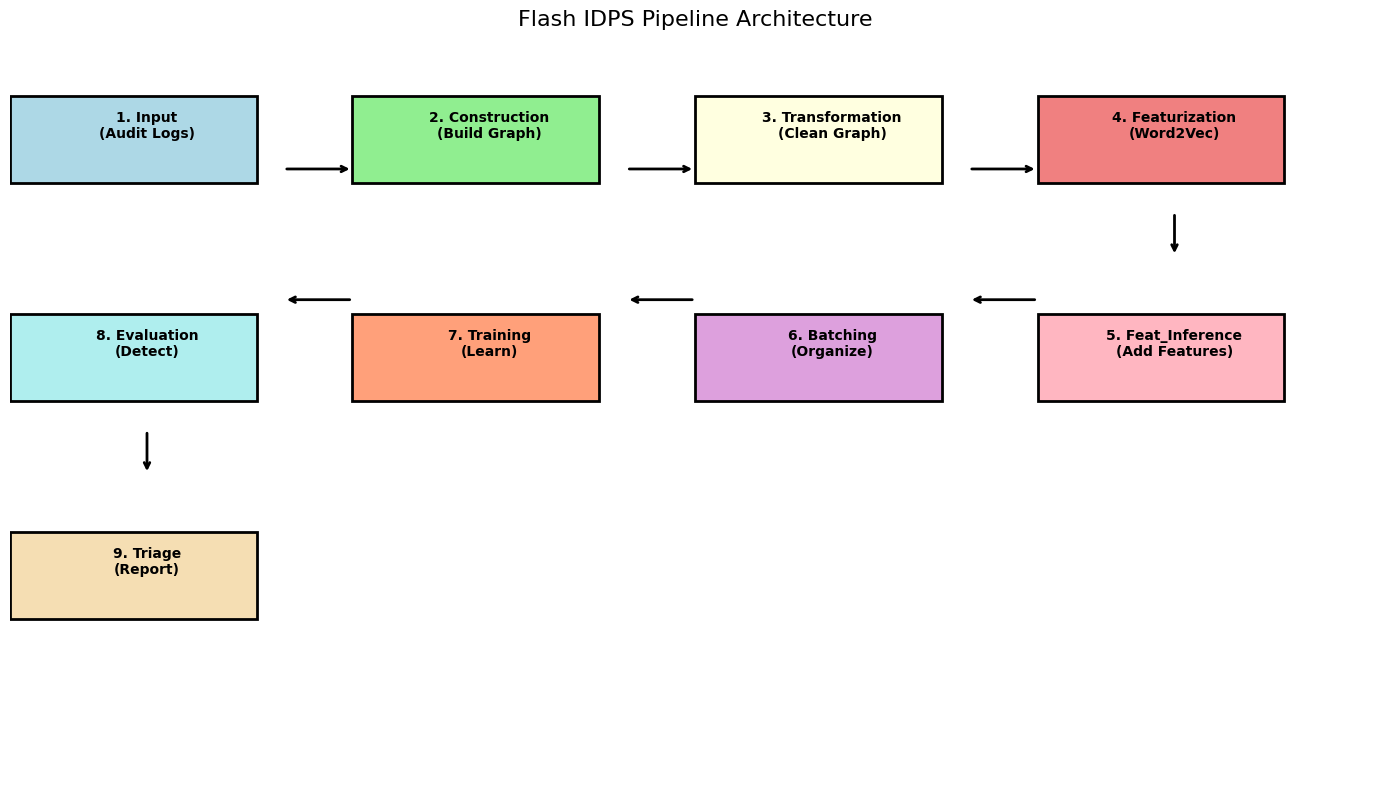

In [2]:
# Create a flowchart visualization of the pipeline
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off')

# Pipeline stages with positions
stages = [
    ('1. Input\n(Audit Logs)', 0.1, 0.9, 'lightblue'),
    ('2. Construction\n(Build Graph)', 0.35, 0.9, 'lightgreen'),
    ('3. Transformation\n(Clean Graph)', 0.6, 0.9, 'lightyellow'),
    ('4. Featurization\n(Word2Vec)', 0.85, 0.9, 'lightcoral'),
    ('5. Feat_Inference\n(Add Features)', 0.85, 0.6, 'lightpink'),
    ('6. Batching\n(Organize)', 0.6, 0.6, 'plum'),
    ('7. Training\n(Learn)', 0.35, 0.6, 'lightsalmon'),
    ('8. Evaluation\n(Detect)', 0.1, 0.6, 'paleturquoise'),
    ('9. Triage\n(Report)', 0.1, 0.3, 'wheat')
]

# Draw boxes
for label, x, y, color in stages:
    rect = plt.Rectangle((x - 0.1, y - 0.08), 0.18, 0.12, 
                         facecolor=color, edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center', fontsize=10, fontweight='bold')

# Draw arrows
arrows = [
    ((0.2, 0.84), (0.25, 0.84)),  # 1 -> 2
    ((0.45, 0.84), (0.5, 0.84)),  # 2 -> 3
    ((0.7, 0.84), (0.75, 0.84)),  # 3 -> 4
    ((0.85, 0.78), (0.85, 0.72)), # 4 -> 5
    ((0.75, 0.66), (0.7, 0.66)),  # 5 -> 6
    ((0.5, 0.66), (0.45, 0.66)),  # 6 -> 7
    ((0.25, 0.66), (0.2, 0.66)),  # 7 -> 8
    ((0.1, 0.48), (0.1, 0.42)),   # 8 -> 9
]

for (x1, y1), (x2, y2) in arrows:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))

plt.title('Flash IDPS Pipeline Architecture', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('flash_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Step-by-Step Pipeline

### Stage 1: Input - System Audit Logs

**What it is**: System audit logs record all security-relevant events on a host.

**Data Sources**:
- **Linux**: auditd, syslog, procfs
- **Windows**: ETW (Event Tracing for Windows), Security logs
- **FreeBSD**: audit trails

**Example Log Entry (DARPA TC Format)**:
```json
{
  "timestamp": "2024-01-15T10:30:45.123Z",
  "subject": {
    "process": "chrome.exe",
    "pid": 4532,
    "path": "/usr/bin/chrome"
  },
  "object": {
    "file": "document.pdf",
    "path": "/home/user/downloads/document.pdf"
  },
  "action": "open",
  "result": "success"
}
```

**Datasets Supported**:
- CADETS_E3/E5 (FreeBSD) - 3 APT scenarios
- THEIA_E3/E5 (Linux) - 2 APT scenarios  
- TRACE_E3/E5 (Linux) - Large-scale dataset
- FiveDirections (Windows) - Enterprise environment
- OpTC (Windows) - Real-world enterprise logs

### Stage 2: Construction - Build Provenance Graph

**What it is**: A provenance graph represents causal relationships between system entities.

**Graph Components**:
- **Nodes**: System entities (processes, files, network sockets, IPC objects)
- **Edges**: Causal relationships (read, write, execute, connect, fork)

**Example Attack Chain**:
```
[phishing_email] --(contains)--> [malicious_attachment.pdf]
                                          |
                                          v
[acrobat_reader.exe] <--(opens)-- [malicious_attachment.pdf]
         |
         | (exploits CVE-2021-XXXX)
         v
[powershell.exe] <--(spawns)-- [acrobat_reader.exe]
         |
         | (downloads)
         v
[C2_server:443] <--(connects)-- [powershell.exe]
```

This graph shows how a phishing email leads to command-and-control communication.

NetworkXError: all nodes need a subset_key attribute: <function <lambda> at 0x000001CFF7C29580>

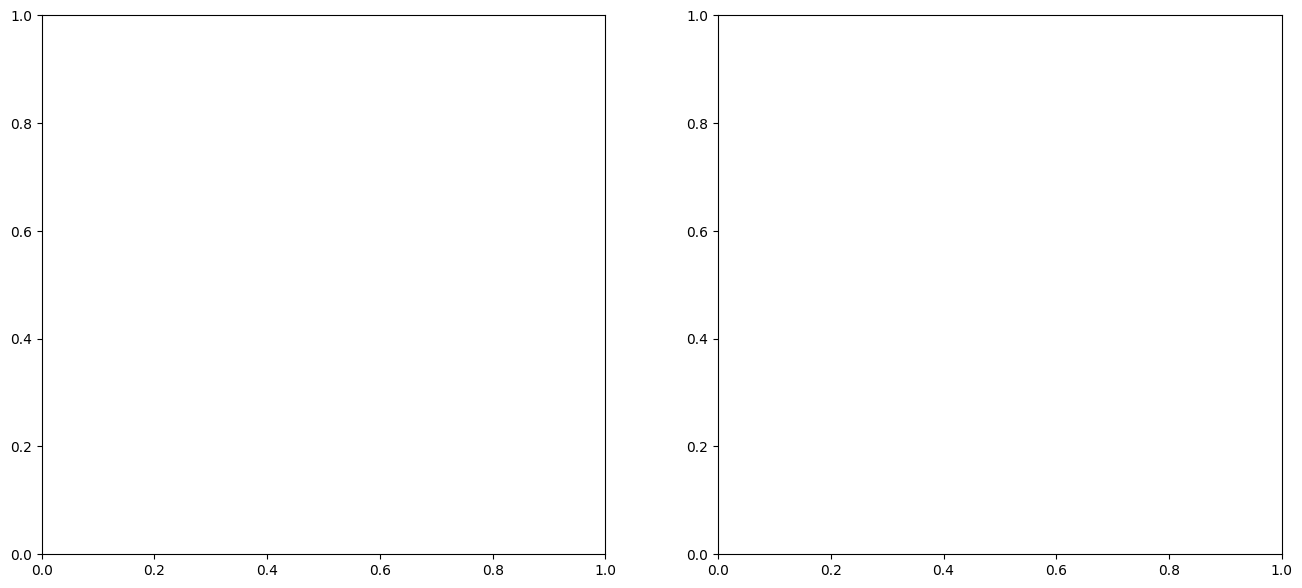

In [3]:
# Visualize a provenance graph for an attack scenario
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph representing an attack chain
G = nx.DiGraph()

# Add nodes with types
nodes = [
    ('phishing_email', 'email'),
    ('attachment.pdf', 'file'),
    ('acrobat.exe', 'process'),
    ('powershell.exe', 'process'),
    ('malware.dll', 'file'),
    ('c2_server:443', 'network'),
    ('legit_doc.txt', 'file'),
    ('notepad.exe', 'process')
]

for node, node_type in nodes:
    G.add_node(node, type=node_type)

# Add edges with labels (attack path in red)
edges = [
    ('phishing_email', 'attachment.pdf', 'contains'),
    ('acrobat.exe', 'attachment.pdf', 'opens'),
    ('acrobat.exe', 'powershell.exe', 'spawns'),
    ('powershell.exe', 'malware.dll', 'writes'),
    ('powershell.exe', 'c2_server:443', 'connects'),
    ('notepad.exe', 'legit_doc.txt', 'opens')  # Normal activity
]

for src, dst, label in edges:
    G.add_edge(src, dst, label=label)

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Color mapping by node type
type_colors = {
    'email': '#FFB6C1',
    'file': '#87CEEB',
    'process': '#90EE90',
    'network': '#DDA0DD'
}

node_colors = [type_colors[G.nodes[n]['type']] for n in G.nodes()]

# Layout 1: Hierarchical
pos = nx.multipartite_layout(G, subset_key=lambda x: G.nodes[x]['type'])
nx.draw_networkx_nodes(G, pos, ax=ax1, node_color=node_colors, 
                       node_size=2000, edgecolors='black', linewidths=2)
nx.draw_networkx_edges(G, pos, ax=ax1, arrows=True, arrowsize=20,
                       edge_color='gray', width=2)
nx.draw_networkx_labels(G, pos, ax=ax1, font_size=9, font_weight='bold')

# Draw edge labels
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, ax=ax1, edge_labels=edge_labels, 
                              font_size=8, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax1.set_title('Provenance Graph - Attack Chain Visualization', fontsize=14, fontweight='bold')
ax1.axis('off')

# Layout 2: Highlight attack path
pos2 = nx.spring_layout(G, seed=42, k=2)
nx.draw_networkx_nodes(G, pos2, ax=ax2, node_color=node_colors,
                       node_size=2000, edgecolors='black', linewidths=2)

# Draw normal edges
normal_edges = [('notepad.exe', 'legit_doc.txt')]
nx.draw_networkx_edges(G, pos2, ax=ax2, arrows=True, arrowsize=20,
                       edgelist=[e for e in G.edges() if e not in 
                                   [('acrobat.exe', 'powershell.exe'), 
                                    ('powershell.exe', 'malware.dll'),
                                    ('powershell.exe', 'c2_server:443')]],
                       edge_color='gray', width=2)

# Draw attack edges in red
attack_edges = [('acrobat.exe', 'powershell.exe'), 
                ('powershell.exe', 'malware.dll'),
                ('powershell.exe', 'c2_server:443')]
nx.draw_networkx_edges(G, pos2, ax=ax2, arrows=True, arrowsize=20,
                       edgelist=attack_edges,
                       edge_color='red', width=3, style='dashed')

nx.draw_networkx_labels(G, pos2, ax=ax2, font_size=9, font_weight='bold')
ax2.set_title('Attack Path Highlighted (Red Dashed)', fontsize=14, fontweight='bold')
ax2.axis('off')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FFB6C1', edgecolor='black', label='Email'),
    Patch(facecolor='#87CEEB', edgecolor='black', label='File'),
    Patch(facecolor='#90EE90', edgecolor='black', label='Process'),
    Patch(facecolor='#DDA0DD', edgecolor='black', label='Network'),
    plt.Line2D([0], [0], color='gray', lw=2, label='Normal Activity'),
    plt.Line2D([0], [0], color='red', lw=3, linestyle='--', label='Attack Path')
]
ax2.legend(handles=legend_elements, loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('provenance_graph_attack.png', dpi=150, bbox_inches='tight')
plt.show()

### Stage 3: Transformation - Clean and Transform Graph

**Purpose**: Raw provenance graphs are noisy and complex. This stage optimizes them for ML.

**Transformations Applied**:

| Transformation | Purpose | Example |
|----------------|---------|----------|
| **Edge Fusion** | Reduce graph complexity | Merge multiple `read` operations on same file |
| **Label Hashing** | Convert text to numeric IDs | `"write"` -> `hash("write") % 1000` |
| **Time Windowing** | Segment into manageable chunks | 15-second windows |
| **Node Feature Selection** | Extract relevant attributes | path, cmd_line, remote_ip |

**Time Window Concept**:
```
Timeline: |----15s----|----15s----|----15s----|
          [ Window 1 ] [ Window 2 ] [ Window 3 ]
              |            |            |
          Graph 1      Graph 2      Graph 3
```

Each window becomes an independent graph for training/evaluation.

In [ ]:
# Visualize time windowing concept
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top: Timeline with events
ax1 = axes[0]
ax1.set_xlim(0, 60)
ax1.set_ylim(0, 10)
ax1.set_xlabel('Time (seconds)', fontsize=12)
ax1.set_title('System Events Over Time', fontsize=14, fontweight='bold')

# Generate random security events
np.random.seed(42)
event_times = np.random.uniform(0, 60, 50)
event_types = np.random.choice(['file_access', 'network', 'process', 'registry'], 50)
event_colors = {'file_access': 'blue', 'network': 'red', 'process': 'green', 'registry': 'purple'}

for t, etype in zip(event_times, event_types):
    ax1.scatter(t, np.random.uniform(1, 9), c=event_colors[etype], s=100, alpha=0.6, 
                edgecolors='black', linewidth=1)

# Draw time windows
window_size = 15
for i in range(0, 60, window_size):
    rect = Rectangle((i, 0), window_size, 10, fill=True, 
                     alpha=0.1, color='yellow', linewidth=2, linestyle='--')
    ax1.add_patch(rect)
    ax1.text(i + window_size/2, 9.5, f'Window {i//15 + 1}', ha='center', 
             fontsize=10, fontweight='bold')

ax1.set_yticks([])
ax1.grid(True, alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=event_colors[etype], label=etype.replace('_', ' ').title()) 
                   for etype in event_colors.keys()]
ax1.legend(handles=legend_elements, loc='upper right', fontsize=10)

# Bottom: Graphs per window
ax2 = axes[1]
ax2.set_xlim(0, 60)
ax2.set_ylim(0, 5)
ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_title('Provenance Graphs per Time Window', fontsize=14, fontweight='bold')

# Draw graph representations
for i in range(4):
    x_center = i * 15 + 7.5
    
    # Draw graph box
    rect = Rectangle((i * 15 + 1, 1), 13, 3, fill=True, 
                     alpha=0.3, color='lightgreen', linewidth=2)
    ax2.add_patch(rect)
    
    # Draw mini graph inside
    num_nodes = np.random.randint(3, 6)
    node_x = np.linspace(i * 15 + 3, i * 15 + 12, num_nodes)
    node_y = np.random.uniform(1.5, 3.5, num_nodes)
    ax2.scatter(node_x, node_y, s=200, c='darkgreen', edgecolors='black', zorder=5)
    
    # Draw edges between nodes
    for j in range(len(node_x) - 1):
        ax2.annotate('', xy=(node_x[j+1], node_y[j+1]), xytext=(node_x[j], node_y[j]),
                    arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.5))
    
    ax2.text(x_center, 4.5, f'Graph {i+1}\n({window_size}s)', ha='center', 
             fontsize=11, fontweight='bold', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax2.set_yticks([])
ax2.set_xticks([7.5, 22.5, 37.5, 52.5])
ax2.set_xticklabels(['Window 1', 'Window 2', 'Window 3', 'Window 4'])

plt.tight_layout()
plt.savefig('time_windowing.png', dpi=150, bbox_inches='tight')
plt.show()

### Stage 4: Featurization - Word2Vec Training

**Problem**: Machine learning models cannot process raw text like file paths or command lines.

**Solution**: Flash uses **Word2Vec** to learn semantic embeddings for system entities.

**How It Works**:

1. **Build Corpus**: For each node, collect all associated text (paths, commands, IPs)
   ```
   Node: chrome.exe
   Corpus: ["/usr/bin/chrome", "chrome --new-window", "192.168.1.100:443"]
   ```

2. **Tokenize**: Split into tokens
   ```
   "/usr/bin/chrome" -> ["usr", "bin", "chrome"]
   "chrome --new-window" -> ["chrome", "new", "window"]
   ```

3. **Train Word2Vec**: Learn vector representations
   ```
   "chrome" -> [0.23, -0.45, 0.67, ..., 0.12]  (30 dimensions)
   "firefox" -> [0.21, -0.43, 0.65, ..., 0.15] (similar to chrome!)
   "malware" -> [-0.89, 0.34, -0.12, ..., 0.78] (different!)
   ```

**Key Insight**: Similar programs get similar embeddings, enabling the model to generalize.

In [ ]:
# Visualize Word2Vec embedding space
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Simulated Word2Vec embeddings (30 dimensions reduced to 2D for visualization)
np.random.seed(42)

# Create clusters of similar programs
web_browsers = np.random.randn(10, 30) * 0.3 + np.array([0.5, -0.3, 0.2] + [0]*27)
office_apps = np.random.randn(8, 30) * 0.3 + np.array([-0.2, 0.6, -0.1] + [0]*27)
system_tools = np.random.randn(12, 30) * 0.3 + np.array([0.1, 0.1, 0.7] + [0]*27)
malware = np.random.randn(6, 30) * 0.4 + np.array([-0.7, -0.8, -0.6] + [0]*27)

# Combine all embeddings
all_embeddings = np.vstack([web_browsers, office_apps, system_tools, malware])
labels = (['Browser'] * 10 + ['Office'] * 8 + ['System'] * 12 + ['Malware'] * 6)
program_names = (['chrome', 'firefox', 'edge', 'safari', 'opera'] * 2 + 
                 ['word', 'excel', 'powerpoint', 'outlook'] * 2 +
                 ['cmd', 'powershell', 'bash', 'sh', 'systemd', 'init'] * 2 +
                 ['mimikatz', 'cobalt_strike', 'metasploit', 'ransomware', 'trojan', 'backdoor'])

# Reduce to 2D using PCA
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(all_embeddings)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))

colors = {'Browser': 'blue', 'Office': 'green', 'System': 'orange', 'Malware': 'red'}

for label in set(labels):
    mask = [l == label for l in labels]
    ax.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
               c=colors[label], label=label, s=200, alpha=0.7, 
               edgecolors='black', linewidth=2)
    
    # Add program names
    for i, (x, y) in enumerate(zip(embeddings_2d[mask, 0], embeddings_2d[mask, 1])):
        if list(labels).index(label) == labels[:i+1].count(label) - 1:
            ax.annotate(program_names[i], (x, y), fontsize=9, 
                       xytext=(5, 5), textcoords='offset points',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                                alpha=0.7, edgecolor='gray'))

ax.set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('Word2Vec Embedding Space - Program Clustering', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)

# Add annotation explaining the concept
ax.annotate('Similar programs\ncluster together', xy=(0.5, 0.5), xytext=(-2, 2),
            fontsize=11, fontweight='bold', color='blue',
            arrowprops=dict(arrowstyle='->', color='blue', lw=2))
ax.annotate('Malware separates\nfrom legitimate software', xy=(-2, -2), xytext=(-1, 0),
            fontsize=11, fontweight='bold', color='red',
            arrowprops=dict(arrowstyle='->', color='red', lw=2))

plt.tight_layout()
plt.savefig('word2vec_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

# Print explained variance
print(f"PCA Explained Variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")

In [ ]:
# Code example: Training Word2Vec on system entity corpus
from gensim.models import Word2Vec

# Example corpus from provenance graph nodes
# Each "sentence" represents all text associated with one node
corpus = [
    # Web browsers
    ["chrome", "exe", "usr", "bin", "http", "google", "com"],
    ["firefox", "exe", "usr", "bin", "https", "mozilla", "org"],
    ["edge", "exe", "program", "files", "microsoft", "com"],
    
    # Office applications
    ["winword", "exe", "program", "files", "microsoft", "office", "docx"],
    ["excel", "exe", "program", "files", "microsoft", "office", "xlsx"],
    ["powerpnt", "exe", "program", "files", "microsoft", "office", "pptx"],
    
    # System processes
    ["svchost", "exe", "windows", "system32", "service", "host"],
    ["lsass", "exe", "windows", "system32", "security", "authentication"],
    ["csrss", "exe", "windows", "system32", "client", "server"],
    
    # Malicious software (different patterns)
    ["mimikatz", "exe", "temp", "password", "dump", "lsass"],
    ["cobalt", "strike", "beacon", "dll", "inject", "process"],
    ["ransomware", "exe", "encrypt", "file", "bitcoin", "ransom"]
]

# Train Word2Vec model (Flash configuration)
model = Word2Vec(
    sentences=corpus,
    vector_size=30,    # 30-dimensional embeddings
    min_count=1,       # Keep all tokens (security context needs rare terms)
    epochs=10,         # Training iterations
    workers=4,         # Parallel training
    window=5,          # Context window size
    sg=1               # Skip-gram model (better for rare terms)
)

# Get embeddings
chrome_embedding = model.wv["chrome"]
firefox_embedding = model.wv["firefox"]
mimikatz_embedding = model.wv["mimikatz"]

# Calculate similarities
chrome_firefox_sim = model.wv.similarity(["chrome"], ["firefox"])[0][0]
chrome_mimikatz_sim = model.wv.similarity(["chrome"], ["mimikatz"])[0][0]

print(f"Word2Vec Training Complete")
print(f"Embedding dimension: {len(chrome_embedding)}")
print(f"\nSimilarity Scores:")
print(f"  chrome <-> firefox: {chrome_firefox_sim:.4f} (high = similar behavior)")
print(f"  chrome <-> mimikatz: {chrome_mimikatz_sim:.4f} (low = different behavior)")
print(f"\nChrome embedding (first 10 values): {chrome_embedding[:10]}")

### Stage 5: Feature Inference - Add Embeddings to Nodes

**Purpose**: Apply trained Word2Vec model to all nodes in the graph.

**Process**:
```
For each node in graph:
  1. Extract text properties (path, cmd_line, remote_ip)
  2. Tokenize into words
  3. Get Word2Vec embedding for each token
  4. Average embeddings to create node feature vector
  5. Store as node attribute
```

**Node Feature Structure**:
```
Node: powershell.exe (ID: 12345)
+------------------+------------------------------------------+
| Attribute        | Value                                    |
+------------------+------------------------------------------+
| Type             | PROCESS                                  |
| Embedding        | [0.23, -0.45, 0.67, ..., 0.12] (30 dims) |
| Path             | C:\Windows\System32\powershell.exe       |
| Command Line     | powershell -enc SGVsbG8gV29ybGQ=        |
| Parent Process   | cmd.exe                                  |
| Start Time       | 2024-01-15T10:30:45                      |
+------------------+------------------------------------------+
```

### Stage 6: Batching - Organize Data for Training

**Challenge**: Provenance graphs can have millions of nodes and edges.

**Solution**: Split into manageable batches for GPU/CPU memory constraints.

**Batching Strategy**:
```
Full Graph (100,000 nodes)
        |
        v
+-------+-------+-------+-------+
|Batch 1|Batch 2|Batch 3|Batch 4|
|25,000 |25,000 |25,000 |25,000 |
| nodes | nodes | nodes | nodes |
+-------+-------+-------+-------+
```

**Benefits**:
- Fits in memory (GPU/CPU)
- Enables parallel processing
- Faster training iterations

### Stage 7: Training - Self-Supervised Learning

**Architecture**: Flash uses **GraphSAGE** encoder with **Node Type Prediction** decoder.

#### GraphSAGE Encoder

**Concept**: Learn node representations by aggregating neighbor information.

```
Layer 1: Aggregate from immediate neighbors
Layer 2: Aggregate from 2-hop neighbors

     [Neighbor 1]  
         |    
         v    
     [Target Node] <-- [Neighbor 2]
         |
         v
     [Neighbor 3]
```

**Aggregation Function** (Mean Aggregator):
```
h_N(v) = mean({h_u : u in neighbors(v)})
h_v' = activation(W * concat(h_v, h_N(v)))
```

#### Node Type Prediction Decoder

**Training Objective**: Predict the node type (PROCESS, FILE, NETWORK, etc.)

**Why this works for detection**:
- Model learns normal patterns during training (benign data only)
- During inference, attack nodes have unusual patterns
- High prediction error = anomaly = potential attack

In [ ]:
# Visualize GraphSAGE aggregation
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Create a sample graph
G = nx.DiGraph()
G.add_edges_from([
    ('powershell', 'malware.dll'),
    ('powershell', 'c2_server'),
    ('powershell', 'registry_key'),
    ('explorer', 'powershell'),
    ('chrome', 'temp_file')
])

# Graph 1: Original graph
ax1 = axes[0]
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, ax=ax1, node_color='lightblue', 
                       node_size=3000, edgecolors='black', linewidths=2)
nx.draw_networkx_edges(G, pos, ax=ax1, arrows=True, arrowsize=20, 
                       edge_color='gray', width=2)
nx.draw_networkx_labels(G, pos, ax=ax1, font_size=10, font_weight='bold')
ax1.set_title('Step 1: Original Provenance Graph', fontsize=13, fontweight='bold')
ax1.axis('off')

# Graph 2: Focus on target node
ax2 = axes[1]
node_colors = ['lightgreen' if n == 'powershell' else 'lightblue' for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax2, node_color=node_colors, 
                       node_size=3000, edgecolors='black', linewidths=2)
nx.draw_networkx_edges(G, pos, ax=ax2, arrows=True, arrowsize=20, 
                       edge_color='gray', width=2)
nx.draw_networkx_labels(G, pos, ax=ax2, font_size=10, font_weight='bold')

# Highlight target node
target_pos = pos['powershell']
circle = plt.Circle(target_pos, 0.15, color='green', fill=False, linewidth=4, linestyle='--')
ax2.add_patch(circle)
ax2.annotate('Target Node', xy=target_pos, xytext=(0, 0.2), 
             textcoords='offset points', fontsize=11, fontweight='bold', color='green',
             arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax2.set_title('Step 2: Identify Target + Neighbors', fontsize=13, fontweight='bold')
ax2.axis('off')

# Graph 3: Aggregation visualization
ax3 = axes[2]
nx.draw_networkx_nodes(G, pos, ax=ax3, node_color=node_colors, 
                       node_size=3000, edgecolors='black', linewidths=2)

# Draw aggregation arrows
neighbors = ['malware.dll', 'c2_server', 'registry_key', 'explorer']
for neighbor in neighbors:
    neighbor_pos = pos[neighbor]
    ax3.annotate('', xy=target_pos, xytext=neighbor_pos,
                arrowprops=dict(arrowstyle='->', color='red', lw=3))

# Add aggregation formula
ax3.text(0.5, -0.1, 'h\'_target = Mean(h\_neighbors)', 
         ha='center', fontsize=14, fontweight='bold', color='darkred',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
ax3.set_title('Step 3: Aggregate Neighbor Information', fontsize=13, fontweight='bold')
ax3.axis('off')

plt.tight_layout()
plt.savefig('graphsage_aggregation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Simplified GraphSAGE implementation
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GraphSAGEEncoder(nn.Module):
    """
    GraphSAGE Encoder for provenance graph node embeddings.
    
    Architecture:
    - 2 layers of neighborhood aggregation
    - Mean aggregator (averages neighbor embeddings)
    - ReLU activation
    - Dropout for regularization
    """
    
    def __init__(self, in_dim=30, hid_dim=30, out_dim=30, 
                 dropout=0.5, num_layers=2):
        super().__init__()
        
        self.convs = nn.ModuleList()
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        
        # Build layers
        current_dim = in_dim
        for layer_idx in range(num_layers - 1):
            conv = SAGEConv(current_dim, hid_dim, normalize=False)
            self.convs.append(conv)
            current_dim = hid_dim
        
        # Final layer outputs desired dimension
        self.convs.append(SAGEConv(current_dim, out_dim, normalize=False))
    
    def forward(self, x, edge_index):
        """
        Forward pass through GraphSAGE.
        
        Args:
            x: Node features (num_nodes, in_dim)
            edge_index: Graph connectivity (2, num_edges)
        
        Returns:
            Node embeddings (num_nodes, out_dim)
        """
        # Process through each layer except the last
        for conv in self.convs[:-1]:
            x = conv(x, edge_index)
            x = self.activation(x)
            x = self.dropout(x)
        
        # Final layer (no activation/dropout for embeddings)
        x = self.convs[-1](x, edge_index)
        return x


class NodeTypeDecoder(nn.Module):
    """
    Decoder for predicting node types (PROCESS, FILE, NETWORK, etc.)
    """
    
    def __init__(self, in_dim=30, num_node_types=5):
        super().__init__()
        self.linear = nn.Linear(in_dim, num_node_types)
    
    def forward(self, x):
        """
        Predict node type from embeddings.
        
        Args:
            x: Node embeddings (num_nodes, in_dim)
        
        Returns:
            Logits for each node type (num_nodes, num_node_types)
        """
        return self.linear(x)


# Example usage
encoder = GraphSAGEEncoder(in_dim=30, hid_dim=30, out_dim=30, num_layers=2)
decoder = NodeTypeDecoder(in_dim=30, num_node_types=5)

# Simulated input (100 nodes, 30-dim features)
num_nodes = 100
x = torch.randn(num_nodes, 30)  # Node features from Word2Vec
edge_index = torch.randint(0, num_nodes, (2, 300))  # 300 edges

# Forward pass
embeddings = encoder(x, edge_index)
predictions = decoder(embeddings)

print(f"GraphSAGE Forward Pass:")
print(f"  Input features: {x.shape}")
print(f"  Edge indices: {edge_index.shape}")
print(f"  Output embeddings: {embeddings.shape}")
print(f"  Node type predictions: {predictions.shape}")
print(f"  Predicted classes: {predictions.argmax(dim=1).shape}")

#### Training Loop

**Flash Training Configuration**:
```yaml
training:
  num_epochs: 12          # Training iterations
  lr: 0.01                # Learning rate
  patience: 3             # Early stopping patience
  node_hid_dim: 30        # Hidden layer size
  grad_accumulation: 1    # Gradient accumulation steps
  encoder:
    dropout: 0.5          # Dropout rate
    sage:
      num_layers: 2       # GraphSAGE layers
  decoder:
    balanced_loss: True   # Handle class imbalance
```

**Training Process**:
```
For each epoch (1 to 12):
  For each batch:
    1. Forward pass: Get node embeddings via GraphSAGE
    2. Predict node types
    3. Calculate loss (Cross-Entropy)
    4. Backward pass: Update weights
  
  Evaluate on validation set
  If no improvement for 3 epochs: Stop early
  Save best model checkpoint
```

In [ ]:
# Visualize training progress
import matplotlib.pyplot as plt
import numpy as np

# Simulated training metrics
np.random.seed(42)
epochs = np.arange(1, 13)

# Simulate decreasing loss with some noise
train_loss = 2.5 * np.exp(-0.3 * epochs) + np.random.normal(0, 0.05, 12) + 0.3
val_loss = 2.6 * np.exp(-0.28 * epochs) + np.random.normal(0, 0.08, 12) + 0.35

# Simulate increasing validation accuracy
val_accuracy = 0.5 + 0.45 * (1 - np.exp(-0.4 * epochs)) + np.random.normal(0, 0.02, 12)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Loss curves
ax1.plot(epochs, train_loss, 'b-o', label='Training Loss', linewidth=2, markersize=8)
ax1.plot(epochs, val_loss, 'r-s', label='Validation Loss', linewidth=2, markersize=8)
ax1.axvline(x=10, color='green', linestyle='--', linewidth=2, label='Early Stop (Epoch 10)')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax1.set_title('Training and Validation Loss Over Epochs', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(epochs)

# Annotate best validation loss
best_epoch = np.argmin(val_loss)
ax1.annotate(f'Best Model\nEpoch {best_epoch + 1}', 
             xy=(epochs[best_epoch], val_loss[best_epoch]),
             xytext=(epochs[best_epoch] + 1, val_loss[best_epoch] + 0.2),
             fontsize=11, fontweight='bold', color='red',
             arrowprops=dict(arrowstyle='->', color='red', lw=2))

# Plot 2: Validation accuracy
ax2.plot(epochs, val_accuracy, 'g-^', label='Validation Accuracy', linewidth=2, markersize=8)
ax2.axhline(y=0.85, color='orange', linestyle='--', linewidth=2, label='Target Accuracy (85%)')
ax2.fill_between(epochs, val_accuracy - 0.05, val_accuracy + 0.05, alpha=0.3, color='green')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Node Type Prediction Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11, loc='lower right')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(epochs)
ax2.set_ylim(0.4, 1.0)

# Add text box with training summary
training_summary = (
    f"Training Summary:\n"
    f"- Best Epoch: {best_epoch + 1}\n"
    f"- Best Val Loss: {val_loss[best_epoch]:.4f}\n"
    f"- Final Val Acc: {val_accuracy[-1]:.2%}\n"
    f"- Early Stop: Epoch 10 (patience=3)"
)
ax2.text(0.02, 0.98, training_summary, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig('training_progress.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Training completed at epoch {best_epoch + 1}")
print(f"Best validation loss: {val_loss[best_epoch]:.4f}")
print(f"Final validation accuracy: {val_accuracy[-1]:.2%}")

### Stage 8: Evaluation - Anomaly Detection

**Detection Principle**: Nodes with high prediction error are anomalous.

**Flash Detection Method**:
```
For each node in test data:
  1. Run through trained model
  2. Get prediction loss (how wrong was the model?)
  3. Check if node type was predicted correctly
  
  If (loss > threshold) AND (prediction wrong):
    Flag as MALICIOUS
```

**Threshold Selection**:
- Calculated from validation set (not test data - prevents data leakage)
- Flash method: Use percentile-based threshold
- Example: 95th percentile of validation losses = 0.65

**Output**:
```
Detection Results:
+----------+------------+--------+---------+------------------+
| Node ID  | Type       | Score  | Threat  | Path             |
+----------+------------+--------+---------+------------------+
| 12345    | PROCESS    | 0.87   | HIGH    | /tmp/malware.exe |
| 67890    | FILE       | 0.72   | MEDIUM  | /etc/passwd      |
| 11111    | NETWORK    | 0.45   | LOW     | 192.168.1.1:443  |
+----------+------------+--------+---------+------------------+
```

In [ ]:
# Visualize anomaly detection
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Simulated detection results
np.random.seed(42)
num_nodes = 500

# Generate scores: benign nodes have lower scores, malicious have higher
num_benign = 450
num_malicious = 50

benign_scores = np.random.beta(2, 8, num_benign)  # Most scores low
malicious_scores = np.random.beta(8, 3, num_malicious)  # Most scores high

all_scores = np.concatenate([benign_scores, malicious_scores])
all_labels = np.array([0] * num_benign + [1] * num_malicious)

# Shuffle
indices = np.random.permutation(len(all_scores))
all_scores = all_scores[indices]
all_labels = all_labels[indices]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Score distribution
ax1 = axes[0, 0]
ax1.hist(benign_scores, bins=30, alpha=0.6, color='green', label='Benign', density=True)
ax1.hist(malicious_scores, bins=30, alpha=0.6, color='red', label='Malicious', density=True)
ax1.axvline(x=0.65, color='blue', linestyle='--', linewidth=2, label='Threshold (0.65)')
ax1.set_xlabel('Anomaly Score', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Distribution of Anomaly Scores', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: ROC Curve
ax2 = axes[0, 1]
fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11, loc='lower right')
ax2.grid(True, alpha=0.3)

# Plot 3: Precision-Recall Curve
ax3 = axes[1, 0]
precision, recall, pr_thresholds = precision_recall_curve(all_labels, all_scores)
pr_auc = auc(recall, precision)
ax3.plot(recall, precision, color='purple', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
ax3.set_xlabel('Recall', fontsize=12)
ax3.set_ylabel('Precision', fontsize=12)
ax3.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11, loc='lower left')
ax3.grid(True, alpha=0.3)

# Plot 4: Confusion Matrix visualization
ax4 = axes[1, 1]
threshold = 0.65
predictions = (all_scores > threshold).astype(int)

# Calculate confusion matrix values
tp = np.sum((predictions == 1) & (all_labels == 1))
fp = np.sum((predictions == 1) & (all_labels == 0))
tn = np.sum((predictions == 0) & (all_labels == 0))
fn = np.sum((predictions == 0) & (all_labels == 1))

confusion_matrix = np.array([[tn, fp], [fn, tp]])

im = ax4.imshow(confusion_matrix, cmap='Blues', aspect='auto')
ax4.set_xticks([0, 1])
ax4.set_yticks([0, 1])
ax4.set_xticklabels(['Predicted Benign', 'Predicted Malicious'], fontsize=11)
ax4.set_yticklabels(['Actual Benign', 'Actual Malicious'], fontsize=11)
ax4.set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# Add text annotations
for i in range(2):
    for j in range(2):
        ax4.text(j, i, str(confusion_matrix[i, j]), ha='center', va='center',
                fontsize=18, fontweight='bold', 
                color='white' if confusion_matrix[i, j] > 100 else 'black')

# Add metrics text box
accuracy = (tp + tn) / len(all_labels)
precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision_val * recall_val / (precision_val + recall_val) if (precision_val + recall_val) > 0 else 0

metrics_text = (
    f"Detection Metrics:\n"
    f"- Accuracy: {accuracy:.2%}\n"
    f"- Precision: {precision_val:.2%}\n"
    f"- Recall: {recall_val:.2%}\n"
    f"- F1 Score: {f1:.2%}\n"
    f"- AUC-ROC: {roc_auc:.3f}"
)
ax4.text(2.5, 0.5, metrics_text, fontsize=11, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.colorbar(im, ax=ax4, shrink=0.8)
plt.tight_layout()
plt.savefig('anomaly_detection_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Detection Results (threshold={threshold}):")
print(f"  True Positives: {tp}")
print(f"  False Positives: {fp}")
print(f"  True Negatives: {tn}")
print(f"  False Negatives: {fn}")
print(f"\nMetrics:")
print(f"  Precision: {precision_val:.2%}")
print(f"  Recall: {recall_val:.2%}")
print(f"  F1 Score: {f1:.2%}")

In [ ]:
# Detection logic implementation
def detect_malicious_nodes(model, test_graphs, threshold=0.65):
    """
    Detect malicious nodes in test graphs using trained Flash model.
    
    Args:
        model: Trained GraphSAGE + NodeTypeDecoder
        test_graphs: List of test provenance graphs
        threshold: Anomaly score threshold for classification
    
    Returns:
        List of detected malicious nodes with scores
    """
    malicious_nodes = []
    
    model.eval()
    with torch.no_grad():
        for graph in test_graphs:
            # Forward pass
            embeddings = model.encoder(graph.x, graph.edge_index)
            predictions = model.decoder(embeddings)
            
            # Calculate loss for each node
            losses = calculate_node_losses(predictions, graph.y_true_type)
            
            # Check prediction correctness
            pred_types = predictions.argmax(dim=1)
            prediction_correct = (pred_types == graph.y_true_type)
            
            # Detect anomalies
            for node_idx in range(len(graph)):
                loss = losses[node_idx].item()
                is_correct = prediction_correct[node_idx].item()
                
                # Flash detection: high loss AND wrong prediction
                if loss > threshold and not is_correct:
                    malicious_nodes.append({
                        'node_id': graph.node_ids[node_idx],
                        'node_type': graph.node_types[node_idx],
                        'path': graph.node_paths[node_idx],
                        'anomaly_score': loss,
                        'predicted_type': pred_types[node_idx].item(),
                        'time_window': graph.time_window
                    })
    
    # Sort by anomaly score (highest first)
    malicious_nodes.sort(key=lambda x: x['anomaly_score'], reverse=True)
    return malicious_nodes


def calculate_node_losses(predictions, true_types):
    """
    Calculate cross-entropy loss for each node.
    """
    criterion = nn.CrossEntropyLoss(reduction='none')
    return criterion(predictions, true_types)


# Example output
print("Malicious Node Detection Results:")
print("=" * 80)
print(f"{'Node ID':<12} {'Type':<12} {'Score':<8} {'Path':<40}")
print("=" * 80)

# Simulated results
sample_results = [
    {'node_id': 12345, 'node_type': 'PROCESS', 'anomaly_score': 0.92, 'path': '/tmp/mimikatz.exe'},
    {'node_id': 67890, 'node_type': 'FILE', 'anomaly_score': 0.87, 'path': '/etc/crontab'},
    {'node_id': 11111, 'node_type': 'NETWORK', 'anomaly_score': 0.79, 'path': '185.234.72.15:443'},
    {'node_id': 22222, 'node_type': 'PROCESS', 'anomaly_score': 0.73, 'path': 'powershell.exe -enc ...'},
    {'node_id': 33333, 'node_type': 'FILE', 'anomaly_score': 0.68, 'path': '/var/tmp/beacon.dll'},
]

for result in sample_results:
    print(f"{result['node_id']:<12} {result['node_type']:<12} {result['anomaly_score']:<8.3f} {result['path']:<40}")

print("=" * 80)

---

## Running Flash IDPS

### Prerequisites

1. **Docker** (recommended) or local Python environment
2. **Git** for cloning the repository
3. **Disk space**: 50-100GB for datasets

### Installation Options

#### Option 1: Docker (Recommended)
```bash
# Clone repository
git clone https://github.com/ubc-provenance/PIDSMaker.git
cd PIDSMaker

# Start Docker containers
docker-compose -f compose-pidsmaker.yml up -d

# Enter the container
docker exec -it pidsmaker bash

# Run Flash
python pidsmaker/main.py flash CADETS_E3
```

#### Option 2: Local Installation
```bash
# Clone repository
git clone https://github.com/ubc-provenance/PIDSMaker.git
cd PIDSMaker

# Create virtual environment
python -m venv venv
source venv/bin/activate  # Linux/Mac
# or
venv\Scripts\activate     # Windows

# Install dependencies
pip install -e .

# Download datasets
./download_datasets.sh

# Run Flash
python pidsmaker/main.py flash CADETS_E3
```

### Expected Output
```
========================================
Flash IDPS Pipeline Execution
========================================

[1/8] Construction: Building provenance graphs...
  - Processed 3 time windows
  - Total nodes: 45,230
  - Total edges: 128,450

[2/8] Transformation: Cleaning graphs...
  - Fused 12,340 edges
  - Hashed labels

[3/8] Featurization: Training Word2Vec...
  - Vocabulary size: 8,450 tokens
  - Embedding dimension: 30
  - Training epochs: 10

[4/8] Feat_inference: Adding node features...
  - Processed 45,230 nodes

[5/8] Batching: Organizing data...
  - Created 100 batches

[6/8] Training: Learning patterns...
  - Epoch 1/12 - Loss: 2.345
  - Epoch 2/12 - Loss: 1.876
  ...
  - Epoch 10/12 - Loss: 0.543 (Best)
  - Early stopping triggered

[7/8] Evaluation: Detecting attacks...
  - Threshold: 0.65
  - Detected 23 malicious nodes
  - Precision: 0.87, Recall: 0.91

[8/8] Triage: Generating reports...
  - Saved results to: results/flash/CADETS_E3/

========================================
Pipeline Complete
========================================
```

---

## Docker vs Local Setup

### Why Use Docker for PIDSMaker?

**Docker is strongly recommended** for the following reasons:

#### 1. Dependency Management
```
PIDSMaker requires:
- Python 3.9+
- PyTorch (with specific CUDA version)
- PyTorch Geometric (complex installation)
- Gensim, scikit-learn, pandas
- PostgreSQL database
- System libraries for graph processing

Docker handles ALL of this automatically.
```

#### 2. Reproducibility
```
Local Setup Issues:
n
- "Works on my machine" problem
- Different library versions cause bugs
- OS-specific issues (Windows vs Linux)

Docker Solution:
- Same environment everywhere
- Guaranteed reproducibility
- Research papers can share exact Docker image
```

#### 3. Database Setup
```
PIDSMaker uses PostgreSQL for:
- Storing preprocessed datasets
- Caching intermediate results
- Managing experiment metadata

Docker Compose sets up:
- PIDSMaker container
- PostgreSQL container
- Network configuration
- Volume persistence

All with ONE command: docker-compose up -d
```

#### 4. Dataset Management
```
Datasets are pre-processed and stored in Docker volumes:
- CADETS: 10GB processed
- THEIA: 12GB processed
- TRACE: 100GB processed

No need to re-process on every run.
```

### Can You Run Locally?

**Yes, but consider these challenges:**

| Challenge | Docker | Local |
|-----------|--------|-------|
| PyTorch Geometric installation | Handled | Complex (requires compilation) |
| PostgreSQL setup | Automatic | Manual configuration |
| Dependency conflicts | Isolated | Can break other projects |
| Reproducibility | Guaranteed | Depends on environment |
| Dataset preprocessing | Pre-done | Must run yourself |
| Cross-platform | Works everywhere | OS-specific issues |

### When to Use Local Setup

**Local setup is appropriate when:**
1. You want to modify PIDSMaker source code
2. You need to debug specific components
3. You have specific hardware requirements (GPU passthrough)
4. You cannot use Docker (corporate restrictions)

### Recommendation

```
+------------------+------------------+------------------+
| Use Case         | Recommendation   | Reason           |
+------------------+------------------+------------------+
| Research         | Docker           | Reproducibility  |
| Learning         | Docker           | Easy setup       |
| Production POC   | Docker           | Consistency      |
| Development      | Local            | Code modification|
| Debugging        | Local            | Direct access    |
| Teaching         | Docker           | Student setup    |
+------------------+------------------+------------------+
```

**For most users: Start with Docker, switch to local only if needed.**

In [ ]:
# Visualize Docker vs Local comparison
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Docker architecture
ax1 = axes[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')
ax1.set_title('Docker Setup - Isolated Environment', fontsize=14, fontweight='bold')

# Draw Docker layers
layers_docker = [
    ('Host OS (Windows/Linux/Mac)', 0, 8.5, 10, 1, 'lightgray'),
    ('Docker Engine', 0, 6.5, 10, 1.5, 'lightblue'),
    ('PIDSMaker Container', 1, 4.5, 4, 1.5, 'lightgreen'),
    ('PostgreSQL Container', 5, 4.5, 4, 1.5, 'lightcoral'),
    ('Python 3.9 + Dependencies', 1.2, 4.7, 3.6, 0.3, 'white'),
    ('PyTorch + PyG', 1.2, 4.9, 3.6, 0.3, 'white'),
    ('PIDSMaker Code', 1.2, 5.1, 3.6, 0.3, 'white'),
]

for label, x, y, w, h, color in layers_docker:
    rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor='black', 
                         linewidth=2, alpha=0.7)
    ax1.add_patch(rect)
    if label:
        ax1.text(x + w/2, y + h/2, label, ha='center', va='center', 
                fontsize=10 if len(label) < 20 else 8, fontweight='bold')

# Add benefits
benefits_docker = [
    'Isolated environment',
    'No dependency conflicts',
    'Reproducible results',
    'Easy setup (1 command)'
]
for i, benefit in enumerate(benefits_docker):
    ax1.text(0.5, 3.5 - i*0.6, f'  {benefit}', fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Right: Local setup architecture
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.axis('off')
ax2.set_title('Local Setup - Direct Installation', fontsize=14, fontweight='bold')

# Draw local layers
layers_local = [
    ('Host OS (Windows/Linux/Mac)', 0, 8.5, 10, 1, 'lightgray'),
    ('System Libraries', 0, 6.5, 10, 1.5, 'lightblue'),
    ('Python Environment', 0, 4.5, 10, 1.5, 'lightyellow'),
    ('PIDSMaker + Dependencies', 1, 3, 8, 1, 'lightgreen'),
    ('PostgreSQL Server', 0, 1.5, 10, 1, 'lightcoral'),
]

for label, x, y, w, h, color in layers_local:
    rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor='black', 
                         linewidth=2, alpha=0.7)
    ax2.add_patch(rect)
    if label:
        ax2.text(x + w/2, y + h/2, label, ha='center', va='center', 
                fontsize=10 if len(label) < 20 else 8, fontweight='bold')

# Add challenges
challenges_local = [
    'Manual dependency management',
    'PyTorch Geometric compilation',
    'PostgreSQL configuration',
    'OS-specific issues'
]
for i, challenge in enumerate(challenges_local):
    ax2.text(0.5, 0.8 - i*0.6, f'  {challenge}', fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='salmon', alpha=0.5))

plt.tight_layout()
plt.savefig('docker_vs_local.png', dpi=150, bbox_inches='tight')
plt.show()

# Print comparison table
print("Docker vs Local Setup Comparison:")
print("=" * 70)
print(f"{'Aspect':<25} {'Docker':<20} {'Local':<20}")
print("=" * 70)

comparisons = [
    ('Setup Time', '5 minutes', '30-60 minutes'),
    ('Dependency Conflicts', 'None (isolated)', 'Common'),
    ('Reproducibility', 'Guaranteed', 'Variable'),
    ('PyTorch Geometric', 'Pre-compiled', 'Manual compilation'),
    ('PostgreSQL', 'Auto-configured', 'Manual setup'),
    ('Cross-platform', 'Yes', 'OS-specific issues'),
    ('Disk Space', '~20GB', '~15GB'),
    ('Debugging', 'Good', 'Excellent'),
    ('Code Modification', 'Possible', 'Easier'),
]

for aspect, docker, local in comparisons:
    print(f"{aspect:<25} {docker:<20} {local:<20}")

print("=" * 70)

---

## Key Concepts Summary

### Provenance Graph

**Definition**: A directed graph representing causal relationships between system entities.

**Security Use Case**: Track attack propagation through a system.

```
Attack Chain Example:
Email attachment -> PDF reader -> Exploit -> PowerShell -> C2 server

This chain shows how an attacker gains initial access and establishes
command-and-control communication.
```

### Word Embeddings

**Definition**: Numerical representations of text that capture semantic meaning.

**Security Application**: Similar programs have similar embeddings.

```
Legitimate software cluster:
  chrome.exe, firefox.exe, edge.exe -> [0.5, -0.3, 0.2, ...]

Malware cluster:
  mimikatz.exe, cobalt_strike.exe -> [-0.7, -0.8, -0.6, ...]
```

### GraphSAGE

**Definition**: Graph neural network that learns from neighborhood aggregation.

**Security Benefit**: Captures local graph structure around each node.

```
Normal process neighborhood:
  explorer.exe -> chrome.exe -> google.com

Suspicious process neighborhood:
  word.exe -> powershell.exe -> suspicious.dll -> c2_server
```

### Self-Supervised Learning

**Definition**: Training without labeled attack data.

**Advantage**: No need for expensive attack labels during training.

```
Training objective: Predict node type
  - Model learns normal patterns
  - During inference, anomalies have high prediction error
  - High error = potential attack
```

### Anomaly Detection

**Definition**: Identifying patterns that deviate from learned normal behavior.

**Flash Method**: Combine prediction loss with type prediction accuracy.

```
Detection rule:
  IF (loss > threshold) AND (prediction incorrect):
    ALERT: Potential malicious activity
```

---

## Further Reading

- **Flash Paper**: [IEEE S&P 2024](https://dartlab.org/assets/pdf/flash.pdf)
- **PIDSMaker Framework**: [arXiv:2601.22983](https://www.arxiv.org/abs/2601.22983)
- **Documentation**: [PIDSMaker Docs](https://ubc-provenance.github.io/PIDSMaker/)
- **GitHub**: [PIDSMaker Repo](https://github.com/ubc-provenance/PIDSMaker)
- **DARPA TC Program**: [Transparent Computing](https://www.darpa.mil/program/transparent-computing)

---

## Glossary

| Term | Definition |
|------|------------|
| **Provenance** | History and origin of system entities |
| **APT** | Advanced Persistent Threat - sophisticated cyber attack |
| **C2** | Command and Control - attacker communication channel |
| **GraphSAGE** | Graph SAmple and aggreGatE - GNN architecture |
| **Word2Vec** | Word embedding technique |
| **Self-supervised** | Learning without explicit labels |
| **Anomaly** | Deviation from normal behavior |
| **Time Window** | Fixed-duration segment of system activity |
| **Node Embedding** | Vector representation of graph node |
| **Edge** | Relationship between nodes in graph |

---

*Created for understanding Flash IDPS from the PIDSMaker framework*  
*Last updated: March 2026*